<a href="https://colab.research.google.com/github/robinrb7/ObjectDetection_Segmentation/blob/main/Dino_and_Depth.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Step 1: Install necessary libraries (run this in a Colab cell)
!pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu118
!pip install transformers
!pip install pillow requests supervision

Looking in indexes: https://download.pytorch.org/whl/cu118
INFO: pip is looking at multiple versions of torch to determine which version is compatible with other requirements. This could take a while.
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.2/23.2 MB 60.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 875.6/875.6 kB 32.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.1/13.1 MB 80.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 663.9/663.9 MB 2.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 417.9/417.9 MB 3.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 168.4/168.4 MB 6.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 58.1/58.1 MB 9.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 128.2/128.2 MB 8.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 204.1/204.1 MB 5.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 147.8/147.8 MB 7.0

In [ ]:
!pip uninstall torch torchvision torchaudio -y

Found existing installation: torch 2.5.1+cu118
Uninstalling torch-2.5.1+cu118:
  Successfully uninstalled torch-2.5.1+cu118
Found existing installation: torchvision 0.20.1+cu124
Uninstalling torchvision-0.20.1+cu124:
  Successfully uninstalled torchvision-0.20.1+cu124
Found existing installation: torchaudio 2.5.1+cu124
Uninstalling torchaudio-2.5.1+cu124:
  Successfully uninstalled torchaudio-2.5.1+cu124


In [ ]:
# Install PyTorch with CUDA 11.8
!pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu118

Looking in indexes: https://download.pytorch.org/whl/cu118
  Using cached https://download.pytorch.org/whl/cu118/torch-2.6.0%2Bcu118-cp311-cp311-linux_x86_64.whl.metadata (27 kB)
  Using cached https://download.pytorch.org/whl/triton-3.2.0-cp311-cp311-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl.metadata (1.4 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 848.7/848.7 MB 1.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 166.7/166.7 MB 6.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.5/6.5 MB 97.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.3/3.3 MB 92.9 MB/s eta 0:00:00
  Attempting uninstall: triton
    Found existing installation: triton 3.1.0
    Uninstalling triton-3.1.0:
      Successfully uninstalled triton-3.1.0
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
fastai 2.7.18 requires torch<2.6,>=1.10, 

In [ ]:
# Step 2: Import libraries
import torch
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image, ImageDraw
from transformers import AutoProcessor, AutoModelForZeroShotObjectDetection, AutoImageProcessor, AutoModelForDepthEstimation
import requests

In [ ]:
# Step 3: Load the models
model_id = "IDEA-Research/grounding-dino-base"
image_processor_id = "depth-anything/Depth-Anything-V2-Small-hf"

device = "cuda" if torch.cuda.is_available() else "cpu"

In [ ]:
processor = AutoProcessor.from_pretrained(model_id)
detection_model = AutoModelForZeroShotObjectDetection.from_pretrained(model_id).to(device)


/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


preprocessor_config.json:   0%|          | 0.00/457 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/1.24k [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/711k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/125 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/1.74k [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/933M [00:00<?, ?B/s]

In [ ]:
depth_processor = AutoImageProcessor.from_pretrained(image_processor_id)
depth_model = AutoModelForDepthEstimation.from_pretrained(image_processor_id)

preprocessor_config.json:   0%|          | 0.00/775 [00:00<?, ?B/s]

Using a slow image processor as `use_fast` is unset and a slow processor was saved with this model. `use_fast=True` will be the default behavior in v4.48, even if the model was saved with a slow processor. This will result in minor differences in outputs. You'll still be able to use a slow processor with `use_fast=False`.


config.json:   0%|          | 0.00/950 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/99.2M [00:00<?, ?B/s]

In [ ]:
# Step 4: Load the image
url = "https://i.pinimg.com/originals/81/73/53/8173538c785e014b1c13128a20558384.jpg"
image = Image.open(requests.get(url, stream=True).raw)

In [ ]:
# Step 5: Run object detection
text_prompt = "a durian."

inputs = processor(images=image, text=text_prompt, return_tensors="pt").to(device)
with torch.no_grad():
    outputs = detection_model(**inputs)

target_sizes = [image.size[::-1]]

results = processor.post_process_grounded_object_detection(
    outputs,
    inputs.input_ids,
    box_threshold=0.27,
    text_threshold=0.35,
    target_sizes=target_sizes
)

In [ ]:
boxes = results[0]["boxes"].cpu().numpy()
labels = results[0]["labels"]
scores = results[0]["scores"].cpu().numpy()

In [ ]:
# Step 6: Run depth estimation
inputs_depth = depth_processor(images=image, return_tensors="pt")

with torch.no_grad():
    outputs_depth = depth_model(**inputs_depth)
    predicted_depth = outputs_depth.predicted_depth

# Resize depth map to match original image
prediction = torch.nn.functional.interpolate(
    predicted_depth.unsqueeze(1),
    size=image.size[::-1],
    mode="bicubic",
    align_corners=False,
)

In [ ]:
depth_map = prediction.squeeze().cpu().numpy()

In [ ]:
# Step 7: Visualize results
def visualize_results():
    draw = ImageDraw.Draw(image)

    for box, score, label in zip(boxes, scores, labels):
        if len(box) == 4 and score > 0.25:  # Use threshold to filter boxes
            x_min, y_min, x_max, y_max = box
            draw.rectangle([x_min, y_min, x_max, y_max], outline="red", width=3)
            draw.text((x_min, y_min), f"{label}: {score:.2f}", fill="red")

    plt.figure(figsize=(20, 10))
    plt.subplot(1, 2, 1)
    plt.imshow(image)
    plt.title("Detected Objects")
    plt.axis("off")

    plt.subplot(1, 2, 2)
    plt.imshow(depth_map, cmap="viridis")
    plt.title("Depth Map")
    plt.axis("off")
    plt.show()

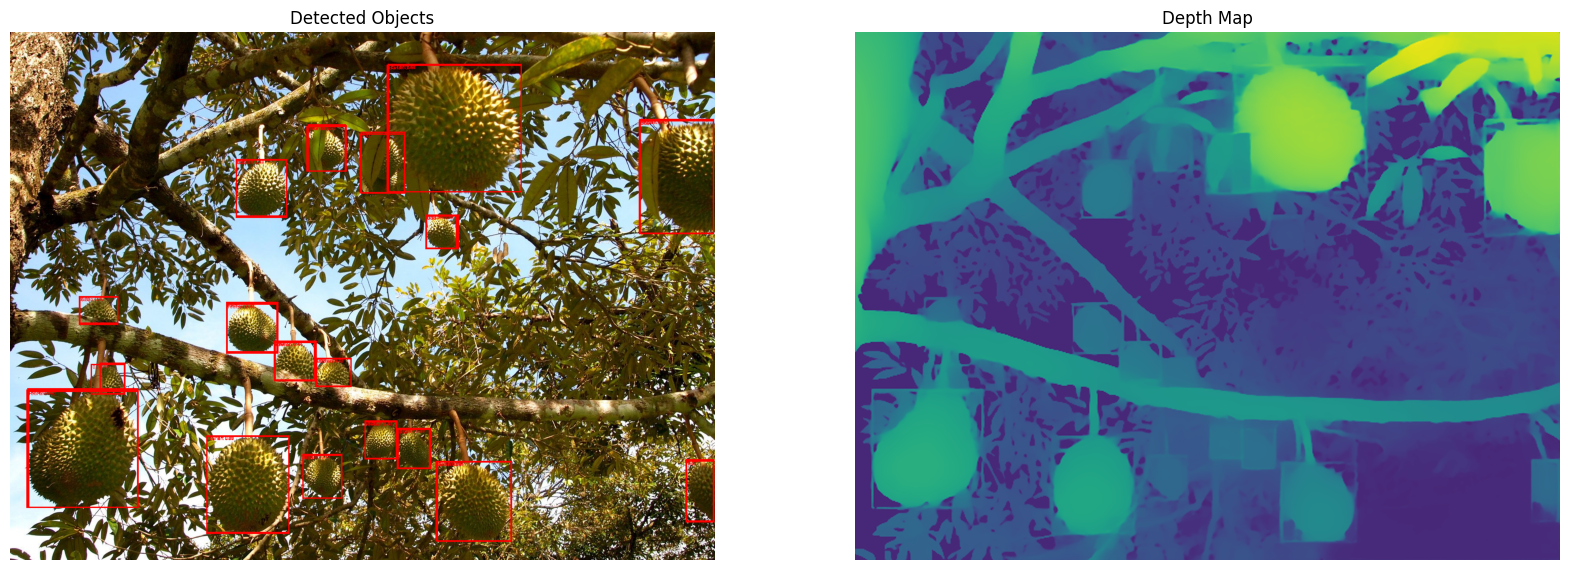

In [ ]:
visualize_results()

In [ ]:
print(boxes)

[[  41.180332  814.22534   291.0931   1079.4344  ]
 [ 854.34143    74.95852  1160.5552    363.8179  ]
 [ 512.966     288.8292    628.3628    418.76312 ]
 [ 491.97385   616.5561    606.9598    726.22675 ]
 [ 965.60516   973.7589   1138.0505   1155.2065  ]
 [ 445.08533   916.1226    633.3196   1136.7065  ]
 [1428.416     198.85559  1596.671     458.63666 ]
 [ 600.5263    703.1043    691.63074   792.50055 ]
 [ 804.86914   883.70325   877.468     968.5133  ]
 [ 942.8668    414.48334  1018.7477    492.91287 ]
 [ 694.2464    740.2682    774.4902    805.3031  ]
 [ 878.2021    898.9824    955.34424   991.9946  ]
 [ 156.62366   599.8989    245.76656   664.4954  ]
 [ 672.1845    213.22751   762.77405   316.51657 ]
 [ 663.62445   957.01556   753.23724  1058.4432  ]
 [ 793.20013   230.41641   895.6233    365.33942 ]
 [ 203.97925   750.97174   261.49585   821.67303 ]]


In [ ]:
# Step 8: Extract depth for each detected object
def get_object_depth():
    object_depths = {}

    for idx, (box, label) in enumerate(zip(boxes, labels)):
        if len(box) == 4:
            x_min, y_min, x_max, y_max = map(int, box)
            object_depth = depth_map[y_min:y_max, x_min:x_max]
            avg_depth = np.mean(object_depth)
            object_name = f"{label}_{idx + 1}"
            object_depths[object_name] = avg_depth

    return object_depths

In [ ]:
object_depths = get_object_depth()

In [ ]:
for obj, depth in object_depths.items():
    print(f"{obj}: Average Depth = {depth:.2f}")

a durian_1: Average Depth = 1.93
a durian_2: Average Depth = 2.89
a durian_3: Average Depth = 1.26
a durian_4: Average Depth = 1.07
a durian_5: Average Depth = 1.34
a durian_6: Average Depth = 1.92
a durian_7: Average Depth = 2.80
a durian_8: Average Depth = 1.37
a durian_9: Average Depth = 1.24
a durian_10: Average Depth = 0.62
a durian_11: Average Depth = 1.25
a durian_12: Average Depth = 1.18
durian_13: Average Depth = 1.12
durian_14: Average Depth = 1.27
a durian_15: Average Depth = 0.97
_16: Average Depth = 1.88
_17: Average Depth = 1.41
